<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/AmesHousing.csv")
df.head()
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.pipeline import Pipeline

In [17]:
x_train,x_test,y_train,y_test=train_test_split(df.drop("SalePrice",axis=1),df["SalePrice"],test_size=0.2,random_state=42)

In [18]:
# Identify categorical and numerical columns
categorical_features = x_train.select_dtypes(include='object').columns
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipe=Pipeline([
    ('preprocessor', preprocessor),
    ("poly",PolynomialFeatures(degree=2)),
    ("model",LinearRegression())
])

In [19]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low...
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('poly', PolynomialFeatures()), ('model', LinearRegression())])

In [21]:
predict=pipe.predict(x_test)

In [22]:
mean_squared_error(y_test,predict)


1793087993.7259998

In [29]:
from sklearn.metrics import r2_score
r2_score(y_test,predict)

0.7763545651141516

In [30]:
linear_model = pipe.named_steps['model']
coefficients = linear_model.coef_
intercept = linear_model.intercept_

print("Coefficients of the hyperplane:")
print(coefficients)
print("\nIntercept of the hyperplane:")
print(intercept)

Coefficients of the hyperplane:
[-7.86768452e-12 -3.36609528e+02 -5.92581066e+00 ...  1.80982500e+01
  0.00000000e+00  2.30172846e+02]

Intercept of the hyperplane:
156086.2710692978


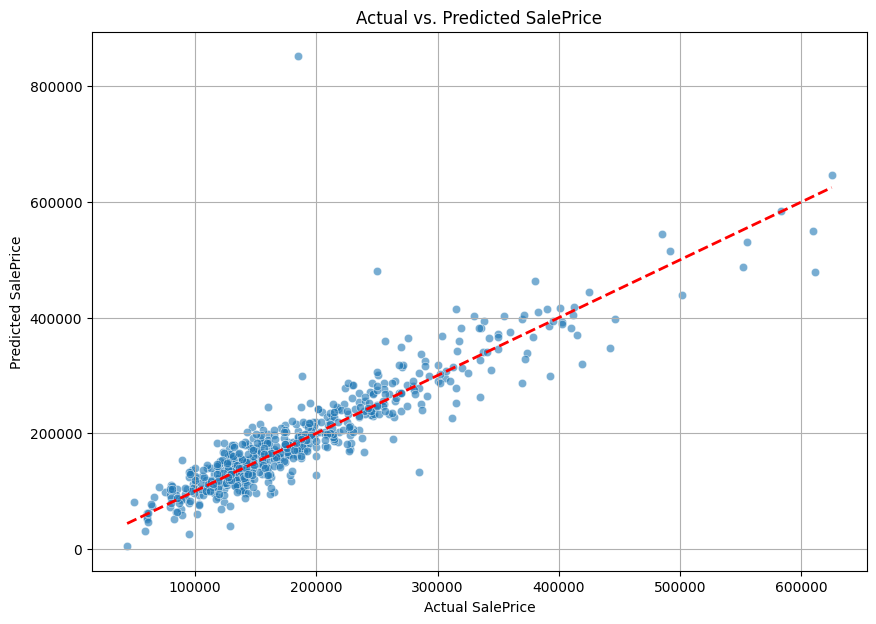

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=predict, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs. Predicted SalePrice')
plt.grid(True)
plt.show()

### Generating Synthetic Data for Polynomial Regression

First, I'll create a synthetic dataset where the relationship between `X` and `y` is clearly non-linear (e.g., quadratic) with some added noise, to simulate real-world data where polynomial regression would be beneficial.

Synthetic data generated successfully.


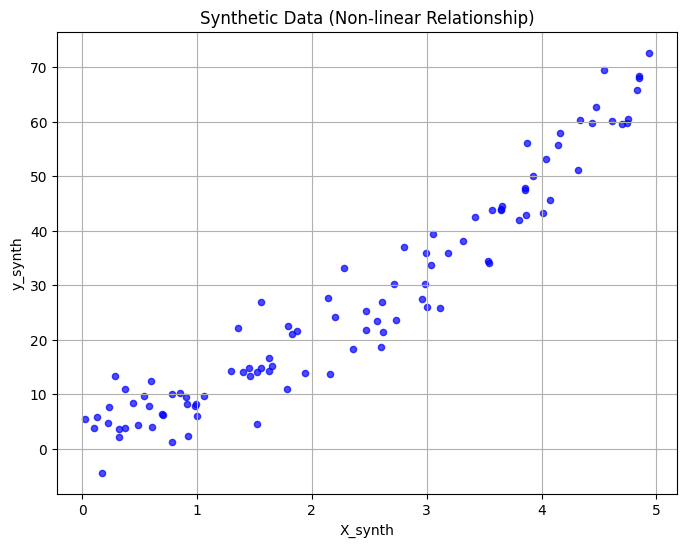

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data with a non-linear relationship
np.random.seed(42)
X_synth = np.sort(5 * np.random.rand(100, 1), axis=0)
y_synth = 2 * X_synth**2 + 3 * X_synth + 5 + np.random.randn(100, 1) * 5

# Split data into training and testing sets
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42)

print("Synthetic data generated successfully.")

# Visualize the synthetic data
plt.figure(figsize=(8, 6))
plt.scatter(X_synth, y_synth, s=20, color='blue', alpha=0.7)
plt.title('Synthetic Data (Non-linear Relationship)')
plt.xlabel('X_synth')
plt.ylabel('y_synth')
plt.grid(True)
plt.show()

### Applying Polynomial Regression

Now, I'll apply polynomial regression to this synthetic data. I'll use a `Pipeline` to first transform the features into polynomial features and then apply a `LinearRegression` model. Given the quadratic nature of the synthetic data, a degree of 2 should fit well.

In [33]:
# Create a Polynomial Regression pipeline
poly_reg_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)), # Using degree 2 to match the data generation
    ('linear', LinearRegression())
])

# Train the model
poly_reg_model.fit(X_train_synth, y_train_synth)

# Make predictions on the test set
y_pred_synth = poly_reg_model.predict(X_test_synth)

# Evaluate the model
mse_synth = mean_squared_error(y_test_synth, y_pred_synth)
r2_synth = r2_score(y_test_synth, y_pred_synth)

print(f"Mean Squared Error for synthetic data: {mse_synth:.2f}")
print(f"R-squared for synthetic data: {r2_synth:.2f}")

Mean Squared Error for synthetic data: 17.34
R-squared for synthetic data: 0.95


### Visualizing Actual vs. Predicted Values

Finally, I'll generate a scatter plot comparing the actual `y_test_synth` values against the `y_pred_synth` values. A diagonal line will indicate a perfect fit.

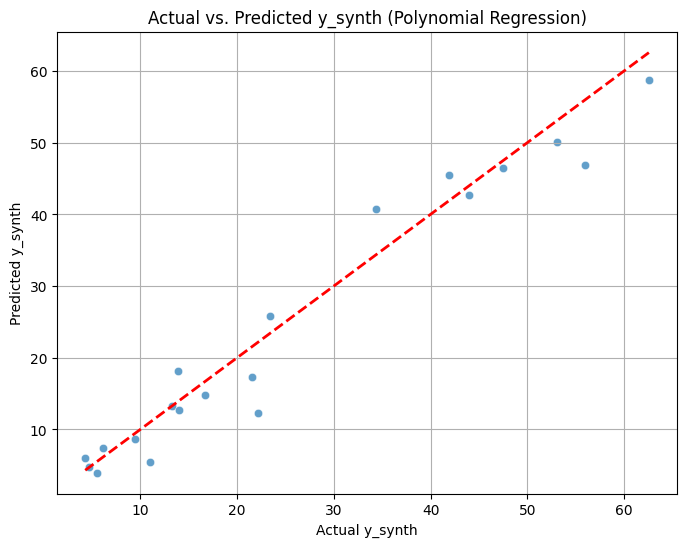

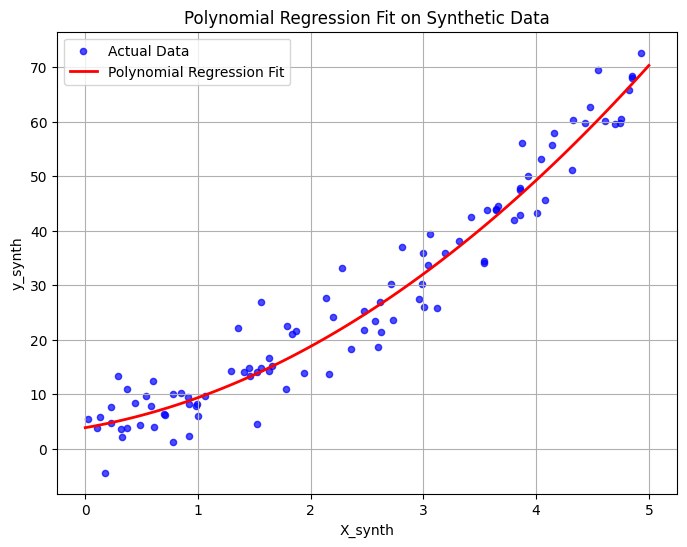

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_synth.flatten(), y=y_pred_synth.flatten(), alpha=0.7)
plt.plot([y_test_synth.min(), y_test_synth.max()], [y_test_synth.min(), y_test_synth.max()], 'r--', lw=2)
plt.xlabel('Actual y_synth')
plt.ylabel('Predicted y_synth')
plt.title('Actual vs. Predicted y_synth (Polynomial Regression)')
plt.grid(True)
plt.show()

# Also visualize the fit line on the original data range
X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
y_plot = poly_reg_model.predict(X_plot)

plt.figure(figsize=(8, 6))
plt.scatter(X_synth, y_synth, s=20, color='blue', alpha=0.7, label='Actual Data')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Polynomial Regression Fit')
plt.title('Polynomial Regression Fit on Synthetic Data')
plt.xlabel('X_synth')
plt.ylabel('y_synth')
plt.legend()
plt.grid(True)
plt.show()